# The Gilded Age Rhyme: Populism, the New Deal, and Now

*An analysis notebook for the Geo-Fluid Dynamics Engine. Exploratory
narrative — the tested library (`geofluid`) does the real computation.*

## The question (plain language)

The 2010s–2020s are often compared to the Gilded Age: concentrated wealth,
disruptive new technology, immigration tensions, and a populist revolt
against elites. That era's revolt — the **People's Party of 1892** — lost,
yo-yoed through the Progressive era, and finally became law in the **New
Deal**. If history rhymes, the geography of the first revolt should still
be legible in later upheavals. Does it rhyme *in the county returns*?

## The bottom line

* **Populism's geography became the New Deal's surprise reservoir.**
  Counties with a large 1892 Populist vote broke above their own forty-year
  trend toward FDR (non-South r = +0.38; still +0.28 against a baseline that
  never sees the 1928 religious anomaly). The revolt lost the election and
  won the future, and you can watch it happen county by county.
* **But the rhyme skipped a beat: Populism did NOT become Progressivism.**
  The 1912 progressive third-party map (Bull Moose + Debs) is uncorrelated
  with the 1892 Populist map. The *ideas* moved into both parties while the
  *places* that first carried them sat out a generation — ideas and
  geography decoupled, then reconverged in 1932.
* **The 2016 echo exists but is not what it looks like.** The positive
  1892→2016 correlation is carried partly by silver-mining counties that
  became resort-economy blue (Aspen was Free Silver country). Deep-time
  echoes are real; naive readings of them are not.

## Honest limits

1892 "other" votes include small Prohibition-party totals alongside the
Populists; Southern returns after 1890 are contaminated by disenfranchisement
(we report the South separately throughout); counties are aggregates, so
nothing here is a claim about individual voters or family transmission —
only about the persistence of *places*.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyreadr

from geofluid.ingest.county_returns import load_county_returns
from geofluid.ingest.historical_returns import load_historical_returns
from geofluid.panel.spine import build_returns_spine
from geofluid.realignment import trend_surprise

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())

hist = load_historical_returns(
    pyreadr.read_r(str(ROOT / "data/raw/_hist_pres.RData"))["pres_elections_release"]
)
modern = load_county_returns(pd.read_csv(ROOT / "data/raw/countypres_2000-2024.csv"))
spine = build_returns_spine(hist, modern)
print(
    f"spine: {len(spine):,} county-years, {spine['year'].nunique()} elections "
    f"{spine['year'].min()}-{spine['year'].max()}"
)

C:\Users\mtgig\working\geo-fluid-dynamics-engine\.venv\Lib\site-packages\pyreadr\_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)
C:\Users\mtgig\working\geo-fluid-dynamics-engine\.venv\Lib\site-packages\pyreadr\_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)


spine: 116,983 county-years, 40 elections 1868-2024


## 1. The Populist ignition map

`dem_share_2p` cannot see the 1892 revolt: Weaver ran *third party*, so the
two-party lens is blind to exactly the thing we care about. The historical
panel carries `other_votes`, and in 1892 "other" is overwhelmingly the
People's Party (plus ~2 points of Prohibition Party nationally — a known
impurity we accept and disclose).

In [2]:
def other_share(year: int) -> "pd.Series[float]":
    y = hist[hist["year"] == year].groupby("fips")[["other_votes", "total_votes"]].sum()
    return (y["other_votes"] / y["total_votes"]).rename(f"other_{year}")


pop_1892 = other_share(1892)  # the Populist revolt
prog_1912 = other_share(1912)  # Bull Moose + Socialists

# Ex-Confederacy states: reported separately throughout because post-1890
# disenfranchisement makes Southern "electorates" incomparable over time.
SOUTH = {"01", "05", "12", "13", "22", "28", "37", "45", "47", "48", "51"}

print(
    f"1892 Populist share: median {pop_1892.median():.1%}, "
    f"p90 {pop_1892.quantile(0.9):.1%}, max {pop_1892.max():.1%}"
)
non_south_top = pop_1892[~pop_1892.index.str[:2].isin(SOUTH)].nlargest(5)
print("top non-South Populist counties (silver-mining West):")
print(non_south_top.round(3).to_string())

1892 Populist share: median 9.8%, p90 48.6%, max 92.0%
top non-South Populist counties (silver-mining West):
fips
32023    0.920
32011    0.920
32013    0.897
08097    0.863
32015    0.844


The wave was intensely concentrated: the median county gave the Populists
under 10%, the top decile over 48%. Outside the South the epicenters are
Nevada and Colorado **silver-mining counties** (Free Silver was the monetary
grievance) plus the Plains — remember the silver counties; they matter for
the 2016 reading below.

## 2. Did Populism become Progressivism? (No.)

The Progressive era is the popular answer to "what did the revolt lead to."
The county returns disagree: the 1912 progressive third-party map (Roosevelt's
Bull Moose 27% + Debs's Socialists 6%) is essentially uncorrelated with the
1892 Populist map. Historians have long described Progressivism as an urban,
middle-class movement rather than the agrarian revolt reborn — the returns
agree quantitatively. The ideas traveled; the places did not.

In [3]:
frame = pd.concat([pop_1892, prog_1912], axis=1).dropna()
frame["south"] = frame.index.str[:2].isin(SOUTH)
for label, sub in [("ALL", frame), ("NON-SOUTH", frame[~frame["south"]])]:
    print(
        f"{label}: corr(populist 1892, progressive 1912) = "
        f"{sub['other_1892'].corr(sub['other_1912']):+.3f}"
    )

ALL: corr(populist 1892, progressive 1912) = -0.067
NON-SOUTH: corr(populist 1892, progressive 1912) = -0.084


## 3. Did Populism become the New Deal? (Yes — and it survives the checks.)

The main test: 1892 Populist share against the 1932 **trend surprise** (how
far each county broke from its own prior forty years in the FDR election —
`geofluid.realignment.trend_surprise`).

Two planned robustness checks:

* **The 1928 problem.** The trend behind 1932 includes 1928, when Al Smith's
  Catholicism cratered the Democratic vote in rural Protestant counties —
  exactly the formerly-Populist ones. A 1932 "surprise" could partly be
  snap-back from that religious anomaly. Check: recompute the outcome as the
  1932 Democratic share minus the county's **1916–1924 average** (a baseline
  that never sees 1928).
* **The 1936 re-target.** A deliberately conservative check with a known
  mechanical bias toward zero: by 1936 the 1932 break is already inside the
  trailing trend window, so trend_surprise has re-baselined onto the
  realigned map and little "surprise" remains to correlate. We report it for
  completeness, expecting attenuation — the informative checks are the
  1928-free baseline and the South split.

In [4]:
surp_1932 = trend_surprise(spine, target_year=1932, value_column="dem_share_2p")
surp_1936 = trend_surprise(spine, target_year=1936, value_column="dem_share_2p")
surp_2016 = trend_surprise(spine, target_year=2016, value_column="dem_share_2p")

wide = spine.pivot_table(index="fips", columns="year", values="dem_share_2p")
smith_free_change = wide[1932] - wide[[1916, 1920, 1924]].mean(axis=1)

deep = pd.concat(
    [
        pop_1892,
        surp_1932.rename("surp_1932"),
        smith_free_change.rename("change_1932_vs_1916_24"),
        surp_1936.rename("surp_1936"),
        surp_2016.rename("surp_2016"),
    ],
    axis=1,
).dropna()
deep["south"] = deep.index.str[:2].isin(SOUTH)

rows = []
for label, sub in [
    ("ALL", deep),
    ("NON-SOUTH", deep[~deep["south"]]),
    ("SOUTH", deep[deep["south"]]),
]:
    rows.append(
        {
            "subset": label,
            "n": len(sub),
            "x surprise 1932": sub["other_1892"].corr(sub["surp_1932"]),
            "x 1932 change (1928-free)": sub["other_1892"].corr(sub["change_1932_vs_1916_24"]),
            "x surprise 1936": sub["other_1892"].corr(sub["surp_1936"]),
            "x surprise 2016": sub["other_1892"].corr(sub["surp_2016"]),
        }
    )
results = pd.DataFrame(rows).set_index("subset").round(3)
print(results.to_string())

              n  x surprise 1932  x 1932 change (1928-free)  x surprise 1936  x surprise 2016
subset                                                                                       
ALL        2649            0.323                      0.242            0.121            0.192
NON-SOUTH  1658            0.384                      0.282            0.095            0.280
SOUTH       991            0.195                      0.069            0.144            0.183


### Reading the table

The main effect (non-South, 1932 surprise) is **+0.38**. Against the
1928-free baseline it is **+0.28** — attenuated, meaning part of the raw
effect was indeed Al Smith snap-back, but a solid reservoir effect remains.
The 1936 re-target lands near zero as the re-baselining predicts (the
reservoir *discharged* in 1932; by 1936 it is the trend). The South is
weaker throughout, as disenfranchisement-era data should be.

## 4. The picture

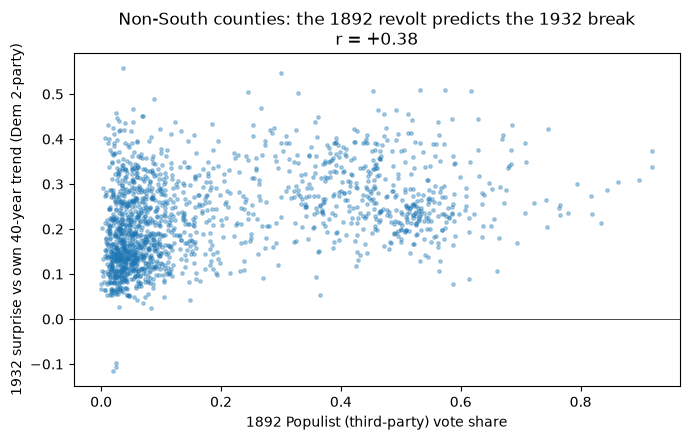

In [5]:
sub = deep[~deep["south"]]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(sub["other_1892"], sub["surp_1932"], s=6, alpha=0.35)
ax.set_xlabel("1892 Populist (third-party) vote share")
ax.set_ylabel("1932 surprise vs own 40-year trend (Dem 2-party)")
ax.set_title(
    "Non-South counties: the 1892 revolt predicts the 1932 break\n"
    f"r = {sub['other_1892'].corr(sub['surp_1932']):+.2f}"
)
ax.axhline(0, lw=0.5, color="k")
plt.tight_layout()
plt.show()

## 5. What this means (and doesn't)

* **The reservoir is real.** Places that revolted in 1892 carried a
  disposition that outlived the party that expressed it, skipped the
  Progressive era's different coalition, and resurfaced 40 years later when
  a major party finally bid for it. This is the deep-time version of the
  engine's core claim: *party is a label; disposition is the signal.*
* **The transmission was not place-to-place contagion through 1912** — the
  Progressive map is different. Realization required a macro shock (the
  Depression) plus a party willing to bid. Structure waits for catalysts:
  the same episodic picture Module 5 sees in the education channel.
* **Modern echoes need unbundling.** The 1892→2016 correlation is positive
  but modest and partly carried by mining-counties-turned-resorts. The 1892
  Populist bundle (economically radical + culturally traditional — Bryan
  prosecuted the Scopes trial) does not map onto either modern party; it
  maps onto the *combination* our False Bastion counties express on ballot
  measures: minimum wage far above partisan lean, abortion at or below it.
  The reservoir's modern address is found by measures, not by candidates.
* **Next (JIT):** county-level historical *referenda* (prohibition,
  suffrage) to watch a full idea-wave rise and fall; NHGIS decennial
  demographics to separate persistence-of-people from replacement-of-people.